# 05. 평가 및 내보내기 (Evaluation & Export)

## 목적
최종 평가, 기존 모델 비교, 프로덕션 Pickle 내보내기

## 주요 작업
1. Leave-One-Out 최종 평가
2. 베이스라인 모델과 비교
3. Head/Torso/Tail 별 성능 분석
4. 프로덕션용 Pickle 내보내기

## 입력
- `pred/models/masked_set_transformer_v1.pt`
- `data/processed/recipe_v3/tokenizer.json`

## 출력
- `pred/models/recipe_gapfilling_v2.pkl` (프로덕션)

In [1]:
# [1단계] Colab 환경 설정 및 Drive 마운트
import sys
import os

# Colab 환경 감지
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # 프로젝트 루트 설정 (본인의 Drive 경로에 맞게 수정)
    PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone'
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, f'{PROJECT_ROOT}/notebooks')

    # 한글 폰트 설치
    print("🔤 한글 폰트 설치 중...")
    import subprocess
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], capture_output=True)

    print(f"✅ Colab 환경 감지")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")
else:
    from pathlib import Path
    PROJECT_ROOT = Path().resolve().parent
    sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

    print("💻 로컬 환경에서 실행 중")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")

Mounted at /content/drive
🔤 한글 폰트 설치 중...
✅ Colab 환경 감지
📁 프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone


In [2]:
# [2단계] 라이브러리 임포트
import json
import pickle
import random
from pathlib import Path
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Colab에서는 문자열을 Path로 변환
if IN_COLAB:
    PROJECT_ROOT = Path(PROJECT_ROOT)
    # 한글 폰트 설정
    import matplotlib.font_manager as fm
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Gap Filling 유틸리티 임포트
from utils.gap_filling import (
    IngredientTokenizer,
    MultiStageNormalizer,
    MaskedSetTransformer,
    LeaveOneOutEvaluator,
    RecipeGapFillingModel
)

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone
CUDA 사용 가능: True


In [3]:
# 경로 설정 (Colab/로컬 자동 감지)
if IN_COLAB:
    from pathlib import Path
    PROJECT_ROOT = Path(PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'recipe_v3'
MODEL_DIR = PROJECT_ROOT / 'pred' / 'models'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"평가 디바이스: {DEVICE}")

평가 디바이스: cuda


## 1. 모델 및 데이터 로드

In [4]:
# 토크나이저 로드
tokenizer = IngredientTokenizer.load(str(DATA_DIR / 'tokenizer.json'))
print(f"토크나이저 로드: vocab_size={tokenizer.vocab_size}")

# 정규화기 초기화
normalizer = MultiStageNormalizer()
print("정규화기 초기화 완료")

토크나이저 로드: vocab_size=12089
정규화기 초기화 완료


In [5]:
# 모델 로드
model_path = MODEL_DIR / 'masked_set_transformer_v1.pt'
model = MaskedSetTransformer.from_pretrained(str(model_path))
model = model.to(DEVICE)
model.eval()

print(f"모델 로드: {model_path}")
print(f"파라미터 수: {model.num_parameters:,}")

모델 로드: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/pred/models/masked_set_transformer_v1.pt
파라미터 수: 7,912,249


In [6]:
# 데이터셋 로드
dataset_info = torch.load(DATA_DIR / 'dataset_info.pt')
train_recipes = dataset_info['train_recipes']
val_recipes = dataset_info['val_recipes']
MAX_LEN = dataset_info['max_len']

print(f"학습 레시피: {len(train_recipes):,}")
print(f"검증 레시피: {len(val_recipes):,}")

학습 레시피: 181,937
검증 레시피: 20,216


In [7]:
# 베이스라인 결과 로드
with open(DATA_DIR / 'baseline_results.json', 'r', encoding='utf-8') as f:
    baseline_results = json.load(f)

print("\n=== 베이스라인 성능 ===")
for model_name in ['random', 'frequency', 'cooccurrence']:
    metrics = baseline_results[model_name]
    print(f"{model_name}: Hit@5 = {metrics['hit_at_5']:.2f}%")


=== 베이스라인 성능 ===
random: Hit@5 = 0.01%
frequency: Hit@5 = 24.51%
cooccurrence: Hit@5 = 28.79%


## 2. Leave-One-Out 평가

In [8]:
# 평가기 초기화
evaluator = LeaveOneOutEvaluator(model, tokenizer, device=DEVICE)

In [9]:
# 전체 검증 세트 평가
print("\n=== Leave-One-Out 평가 (전체 검증 세트) ===")
loo_metrics = evaluator.evaluate_dataset(
    val_recipes,
    k_values=[1, 5, 10],
    max_len=MAX_LEN,
    show_progress=True
)

print(f"\n결과:")
print(f"  Hit@1:  {loo_metrics['hit_at_1']:.2f}%")
print(f"  Hit@5:  {loo_metrics['hit_at_5']:.2f}%")
print(f"  Hit@10: {loo_metrics['hit_at_10']:.2f}%")
print(f"  MRR:    {loo_metrics['mrr']:.4f}")
print(f"  평가 샘플: {loo_metrics['total_samples']:,}")


=== Leave-One-Out 평가 (전체 검증 세트) ===


Leave-One-Out 평가: 100%|██████████| 157161/157161 [08:04<00:00, 324.05it/s]


결과:
  Hit@1:  22.77%
  Hit@5:  48.03%
  Hit@10: 59.50%
  MRR:    0.3353
  평가 샘플: 157,161


## 3. 베이스라인과 비교

In [10]:
# 비교 테이블
comparison = {
    'Model': ['Random', 'Frequency', 'Co-occurrence', 'Masked Set Transformer'],
    'Hit@1': [
        baseline_results['random']['hit_at_1'],
        baseline_results['frequency']['hit_at_1'],
        baseline_results['cooccurrence']['hit_at_1'],
        loo_metrics['hit_at_1']
    ],
    'Hit@5': [
        baseline_results['random']['hit_at_5'],
        baseline_results['frequency']['hit_at_5'],
        baseline_results['cooccurrence']['hit_at_5'],
        loo_metrics['hit_at_5']
    ],
    'Hit@10': [
        baseline_results['random']['hit_at_10'],
        baseline_results['frequency']['hit_at_10'],
        baseline_results['cooccurrence']['hit_at_10'],
        loo_metrics['hit_at_10']
    ],
    'MRR': [
        baseline_results['random']['mrr'],
        baseline_results['frequency']['mrr'],
        baseline_results['cooccurrence']['mrr'],
        loo_metrics['mrr']
    ]
}

df_comparison = pd.DataFrame(comparison)
print("\n=== 모델 성능 비교 ===")
print(df_comparison.to_string(index=False))


=== 모델 성능 비교 ===
                 Model     Hit@1     Hit@5   Hit@10      MRR
                Random  0.000000  0.010000  0.02000 0.000050
             Frequency  8.390000 24.510000 37.86000 0.156668
         Co-occurrence 10.640000 28.790000 40.58000 0.185372
Masked Set Transformer 22.772825 48.026546 59.49504 0.335275


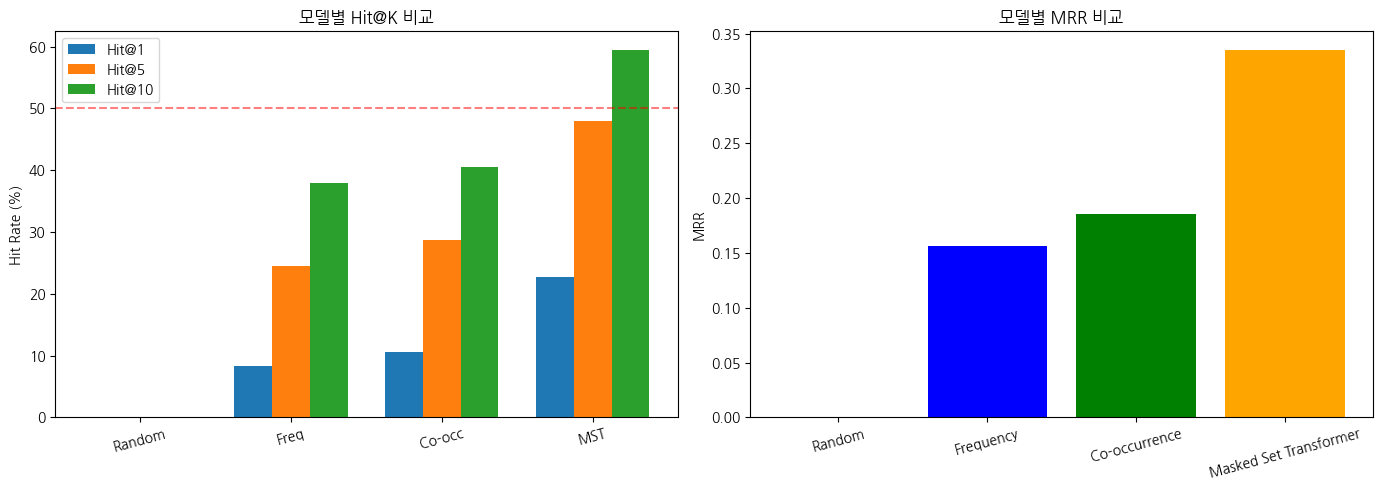

In [11]:
# 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hit@K 비교
x = np.arange(4)
width = 0.25

axes[0].bar(x - width, df_comparison['Hit@1'], width, label='Hit@1')
axes[0].bar(x, df_comparison['Hit@5'], width, label='Hit@5')
axes[0].bar(x + width, df_comparison['Hit@10'], width, label='Hit@10')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Random', 'Freq', 'Co-occ', 'MST'], rotation=15)
axes[0].set_ylabel('Hit Rate (%)')
axes[0].set_title('모델별 Hit@K 비교')
axes[0].legend()
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='목표')

# MRR 비교
colors = ['gray', 'blue', 'green', 'orange']
axes[1].bar(df_comparison['Model'], df_comparison['MRR'], color=colors)
axes[1].set_ylabel('MRR')
axes[1].set_title('모델별 MRR 비교')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(DATA_DIR / 'model_comparison.png', dpi=150)
plt.show()

In [12]:
# 성능 향상 분석
best_baseline = baseline_results['cooccurrence']['hit_at_5']
our_model = loo_metrics['hit_at_5']
improvement = our_model - best_baseline
relative_improvement = improvement / best_baseline * 100

print("\n=== 성능 향상 분석 ===")
print(f"최고 베이스라인 (Co-occurrence): {best_baseline:.2f}%")
print(f"Masked Set Transformer: {our_model:.2f}%")
print(f"절대 향상: +{improvement:.2f}%p")
print(f"상대 향상: +{relative_improvement:.1f}%")

# 목표 달성 여부
target = 50.0
if our_model >= target:
    print(f"\n✅ 목표 달성! (Hit@5 >= {target}%)")
else:
    gap = target - our_model
    print(f"\n⚠️ 목표 미달성. 추가 개선 필요: +{gap:.1f}%p")


=== 성능 향상 분석 ===
최고 베이스라인 (Co-occurrence): 28.79%
Masked Set Transformer: 48.03%
절대 향상: +19.24%p
상대 향상: +66.8%

⚠️ 목표 미달성. 추가 개선 필요: +2.0%p


## 4. Head/Torso/Tail 분석

In [13]:
# 빈도 구간별 평가
freq_bins = {
    'head': (1000, float('inf')),
    'torso': (100, 1000),
    'tail': (5, 100)
}

print("\n=== 빈도 구간별 성능 분석 ===")
freq_results = evaluator.evaluate_by_frequency(
    val_recipes[:5000],  # 샘플링
    freq_bins=freq_bins,
    k=5,
    max_len=MAX_LEN
)

for segment, metrics in freq_results.items():
    print(f"\n{segment.upper()}:")
    print(f"  Hit@5: {metrics['hit_at_5']:.2f}%")
    print(f"  샘플 수: {metrics['total']:,}")


=== 빈도 구간별 성능 분석 ===


빈도별 평가: 100%|██████████| 5000/5000 [02:00<00:00, 41.44it/s]


HEAD:
  Hit@5: 61.71%
  샘플 수: 28,805

TORSO:
  Hit@5: 16.60%
  샘플 수: 5,832

TAIL:
  Hit@5: 2.68%
  샘플 수: 4,408


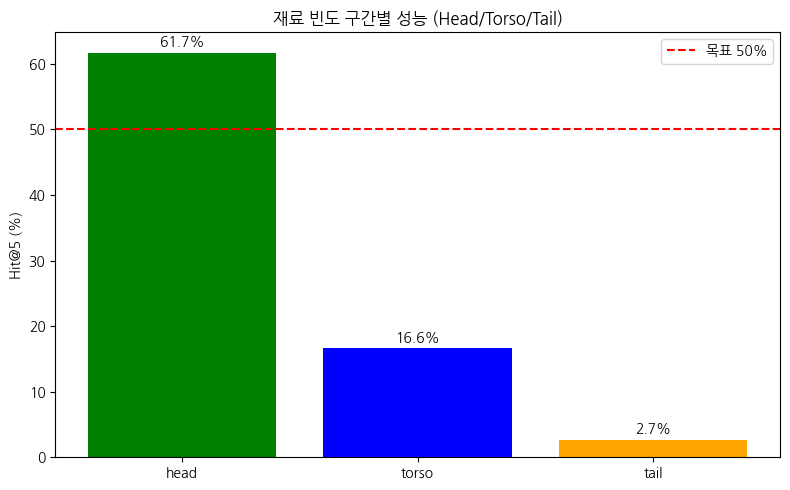

In [14]:
# 빈도 구간별 시각화
segments = list(freq_results.keys())
hit_rates = [freq_results[s]['hit_at_5'] for s in segments]

plt.figure(figsize=(8, 5))
bars = plt.bar(segments, hit_rates, color=['green', 'blue', 'orange'])
plt.axhline(y=50, color='red', linestyle='--', label='목표 50%')
plt.ylabel('Hit@5 (%)')
plt.title('재료 빈도 구간별 성능 (Head/Torso/Tail)')
plt.legend()

# 값 표시
for bar, rate in zip(bars, hit_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center')

plt.tight_layout()
plt.savefig(DATA_DIR / 'freq_segment_performance.png', dpi=150)
plt.show()

## 5. 프로덕션 모델 내보내기

In [15]:
# RecipeGapFillingModel 래퍼 생성
production_model = RecipeGapFillingModel(
    model=model,
    tokenizer=tokenizer,
    normalizer=normalizer,
    device=DEVICE
)

print("프로덕션 모델 래퍼 생성 완료")

프로덕션 모델 래퍼 생성 완료


In [16]:
# 추론 테스트
test_cases = [
    ['돼지고기', '양파', '마늘'],
    ['닭고기', '감자', '당근'],
    ['두부', '된장', '대파'],
    ['계란', '밥', '김치']
]

print("\n=== 추론 테스트 ===")
for ingredients in test_cases:
    recommendations = production_model.recommend(ingredients, top_k=5)
    print(f"\n입력: {ingredients}")
    print(f"추천: {recommendations}")


=== 추론 테스트 ===

입력: ['돼지고기', '양파', '마늘']
추천: ['파', '버섯', '고추가루', '고추', '배추']

입력: ['닭고기', '감자', '당근']
추천: ['양파', '생크림', '호박', '파', '카레가루']

입력: ['두부', '된장', '대파']
추천: ['고추', '고추가루', '돼지고기', '양파', '생크림']

입력: ['계란', '밥', '김치']
추천: ['스팸', '파', '생선', '햄', '치즈']


In [17]:
# 신뢰도 점수와 함께 추천
print("\n=== 신뢰도 점수 포함 추천 ===")
test_input = ['돼지고기', '양파', '마늘']
recommendations_with_scores = production_model.recommend_with_scores(test_input, top_k=10)

print(f"입력: {test_input}\n")
for rank, (ing, score) in enumerate(recommendations_with_scores, 1):
    print(f"  {rank}. {ing}: {score*100:.1f}%")


=== 신뢰도 점수 포함 추천 ===
입력: ['돼지고기', '양파', '마늘']

  1. 파: 19.6%
  2. 버섯: 4.4%
  3. 고추가루: 4.3%
  4. 고추: 4.3%
  5. 배추: 3.6%
  6. 감자: 2.9%
  7. 당근: 2.8%
  8. 파프리카: 2.5%
  9. 조개: 2.1%
  10. 묵은지: 2.0%


In [18]:
# Pickle 파일로 저장
pickle_path = MODEL_DIR / 'recipe_gapfilling_v2.pkl'
production_model.save(str(pickle_path))
print(f"\n프로덕션 모델 저장: {pickle_path}")
print(f"파일 크기: {pickle_path.stat().st_size / 1024 / 1024:.1f} MB")


프로덕션 모델 저장: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/pred/models/recipe_gapfilling_v2.pkl
파일 크기: 42.3 MB


In [19]:
# 저장된 모델 로드 테스트
loaded_model = RecipeGapFillingModel.load(str(pickle_path), device='cpu')
test_result = loaded_model.recommend(['돼지고기', '양파'], top_k=5)
print(f"\n로드 테스트: {test_result}")


로드 테스트: ['파', '감자', '당근', '버섯', '배추']


## 6. 최종 평가 보고서

In [20]:
# 평가 보고서 저장
evaluation_report = {
    'model': 'Masked Set Transformer v1',
    'timestamp': datetime.now().isoformat(),
    'dataset': {
        'train_recipes': len(train_recipes),
        'val_recipes': len(val_recipes),
        'vocab_size': tokenizer.vocab_size
    },
    'overall_metrics': loo_metrics,
    'frequency_analysis': freq_results,
    'comparison': {
        'best_baseline': {
            'model': 'cooccurrence',
            'hit_at_5': best_baseline
        },
        'our_model': our_model,
        'improvement': improvement,
        'relative_improvement': relative_improvement
    },
    'target': {
        'hit_at_5': 50.0,
        'achieved': our_model >= 50.0
    },
    'output_files': {
        'model': str(pickle_path),
        'tokenizer': str(DATA_DIR / 'tokenizer.json')
    }
}

with open(DATA_DIR / 'evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report, f, ensure_ascii=False, indent=2, default=str)

print(f"평가 보고서 저장: {DATA_DIR / 'evaluation_report.json'}")

평가 보고서 저장: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/evaluation_report.json


In [21]:
# 최종 요약 출력
print("\n" + "="*60)
print("🎯 레시피 Gap Filling 모델 v2 - 최종 보고서")
print("="*60)

print("\n📊 모델 정보:")
print(f"  - 아키텍처: Masked Set Transformer (PE 제거)")
print(f"  - 임베딩 차원: 256 (기존 64 → 256)")
print(f"  - 파라미터: {model.num_parameters:,}")
print(f"  - 어휘 크기: {tokenizer.vocab_size:,}")

print("\n📈 성능 지표:")
print(f"  - Hit@1:  {loo_metrics['hit_at_1']:.2f}%")
print(f"  - Hit@5:  {loo_metrics['hit_at_5']:.2f}% {'✅' if loo_metrics['hit_at_5'] >= 50 else '⚠️'}")
print(f"  - Hit@10: {loo_metrics['hit_at_10']:.2f}%")
print(f"  - MRR:    {loo_metrics['mrr']:.4f}")

print("\n📊 베이스라인 대비 개선:")
print(f"  - Co-occurrence 대비: +{improvement:.1f}%p ({relative_improvement:.1f}% 향상)")

print("\n📁 출력 파일:")
print(f"  - {pickle_path}")
print(f"  - {DATA_DIR / 'evaluation_report.json'}")
print(f"  - {DATA_DIR / 'model_comparison.png'}")

print("\n" + "="*60)
if our_model >= 50:
    print("✅ 목표 달성: Hit@5 >= 50%")
else:
    print(f"⚠️ 목표 미달성: Hit@5 = {our_model:.2f}% (목표: 50%)")
print("="*60)


🎯 레시피 Gap Filling 모델 v2 - 최종 보고서

📊 모델 정보:
  - 아키텍처: Masked Set Transformer (PE 제거)
  - 임베딩 차원: 256 (기존 64 → 256)
  - 파라미터: 7,912,249
  - 어휘 크기: 12,089

📈 성능 지표:
  - Hit@1:  22.77%
  - Hit@5:  48.03% ⚠️
  - Hit@10: 59.50%
  - MRR:    0.3353

📊 베이스라인 대비 개선:
  - Co-occurrence 대비: +19.2%p (66.8% 향상)

📁 출력 파일:
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/pred/models/recipe_gapfilling_v2.pkl
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/evaluation_report.json
  - /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/model_comparison.png

⚠️ 목표 미달성: Hit@5 = 48.03% (목표: 50%)
